# Deep Learning A Z Convolucional - MNIST simples

In [1]:
# !pip install tensorflow==2.16.1

In [48]:
#importando as bibliotecas que vai usar
import tensorflow as tf
import keras
import matplotlib
import numpy as np

In [49]:
tf.__version__, keras.__version__, matplotlib.__version__, np.__version__

('2.20.0', '3.13.2', '3.10.8', '2.4.2')

In [50]:
from tensorflow.keras.datasets import mnist # Base de dados MNIST
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import utils as np_utils
import matplotlib.pyplot as plt

In [51]:
(X_treinamento, y_treinamento), (X_teste, y_teste) = mnist.load_data() # fazendo o treinamento

In [52]:
X_treinamento.shape, X_teste.shape # vai ser 60.000 imagens de treinamento e 10.000 imagens de teste

((60000, 28, 28), (10000, 28, 28))

In [53]:
28*28

784

In [54]:
X_treinamento, X_treinamento.max() #vendo o conteudo maximo

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [55]:
y_treinamento #classes dos dígitos

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

Text(0.5, 1.0, 'Classe 5')

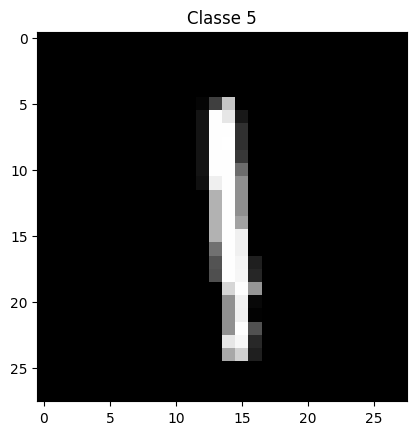

In [56]:
plt.imshow(X_treinamento[8], cmap='gray')
plt.title('Classe ' + str(y_treinamento[0]))

In [57]:
X_treinamento.shape

(60000, 28, 28)

In [58]:
X_treinamento = X_treinamento.reshape(X_treinamento.shape[0], 28, 28, 1) #Utilizando o reshape para que seja possível adicionar a escala de cinza

In [59]:
X_teste = X_teste.reshape(X_teste.shape[0], 28, 28, 1)

In [60]:
X_treinamento.shape, X_teste.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [61]:
X_treinamento = X_treinamento.astype('float32')

In [62]:
X_teste = X_teste.astype('float32')

In [63]:
# dividindo cada valor por 255
X_treinamento /= 255
X_teste /= 255

In [64]:
X_treinamento.max(), X_treinamento.min()

(np.float32(1.0), np.float32(0.0))

In [65]:
y_treinamento

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [66]:
y_treinamento = np_utils.to_categorical(y_treinamento, 10) #utilização do one hot 
y_teste = np_utils.to_categorical(y_teste, 10)

In [67]:
y_treinamento

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [68]:
y_treinamento[8] #indica que o número o 1

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [72]:
rede_neural = Sequential() #criação da rede neural
rede_neural.add(InputLayer(shape =(28, 28, 1))) #camada de entrada
#caamadas convolucionais
rede_neural.add(Conv2D(filters = 32, #quantidade de kernel
                       kernel_size = (3, 3), #tamanho do kernel
                       activation = 'relu')) # função de ativação
    #camada de poling
rede_neural.add(MaxPooling2D(pool_size = (2, 2))) #camada de pooling
    #camada de flatten
rede_neural.add(Flatten()) #transforma a matriz em um vetor
    #rede neural tradicional
rede_neural.add(Dense(units = 128, activation = 'relu'))
rede_neural.add(Dense(units = 10, activation = 'softmax'))

2026-02-23 15:27:10.339481: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [73]:
rede_neural.summary() #melhor para entender a estrutura

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
rede_neural.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy']) #compulação da rede neural

In [76]:
#treinamento 
rede_neural.fit(X_treinamento, y_treinamento, batch_size = 128, 
                epochs = 5, validation_data = (X_teste, y_teste))

Epoch 1/5


2026-02-23 15:29:19.081487: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9369 - loss: 0.2208 - val_accuracy: 0.9767 - val_loss: 0.0797
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9795 - loss: 0.0694 - val_accuracy: 0.9805 - val_loss: 0.0585
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9855 - loss: 0.0477 - val_accuracy: 0.9851 - val_loss: 0.0460
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9893 - loss: 0.0359 - val_accuracy: 0.9845 - val_loss: 0.0458
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9922 - loss: 0.0263 - val_accuracy: 0.9851 - val_loss: 0.0440


In [77]:
resultado = rede_neural.evaluate(X_teste, y_teste)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9851 - loss: 0.0440


In [78]:
resultado

[0.04395240172743797, 0.9850999712944031]

# Melhorias na rede neural

In [80]:
rede_neural = Sequential()#criação a nova rede neural
rede_neural.add(InputLayer(shape =(28, 28, 1))) #camada de entrada
# Camadas convolucionais
rede_neural.add(Conv2D(filters = 32, #quantidade de kernel
                       kernel_size = (3, 3), #tamanho do kernel
                       activation = 'relu')) # função de ativação
rede_neural.add(BatchNormalization())#camada de processamento
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))#camada de pooling

rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

rede_neural.add(Flatten()) #transforma a matriz em um vetor

rede_neural.add(Dense(units = 128, activation = 'relu'))
rede_neural.add(Dropout(0.2))#adicionando camadas de dropout para evitar overfitting
rede_neural.add(Dense(units = 128, activation = 'relu'))
rede_neural.add(Dropout(0.2))
rede_neural.add(Dense(units = 10, activation = 'softmax'))#Utilização de 10 neurônios na camada de saida

In [81]:
rede_neural.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,154 (508.41 KB)

 Trainable params: 130,026 (507.91 KB)

 Non-trainable params: 128 (512.00 B)

In [82]:
rede_neural.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [83]:
rede_neural.fit(X_treinamento, y_treinamento, batch_size=128,
                epochs=5, validation_data = (X_teste, y_teste))

Epoch 1/5


2026-02-23 15:40:24.874457: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9374 - loss: 0.2047 - val_accuracy: 0.9649 - val_loss: 0.1276
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.9816 - loss: 0.0635 - val_accuracy: 0.9903 - val_loss: 0.0313
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9862 - loss: 0.0454 - val_accuracy: 0.9900 - val_loss: 0.0321
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9896 - loss: 0.0361 - val_accuracy: 0.9910 - val_loss: 0.0299
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9911 - loss: 0.0294 - val_accuracy: 0.9912 - val_loss: 0.0296


In [84]:
resultado = rede_neural.evaluate(X_teste, y_teste)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9912 - loss: 0.0296


In [85]:
resultado

[0.029560092836618423, 0.9911999702453613]

In [86]:
resultado

[0.029560092836618423, 0.9911999702453613]